(fitting_distributions)=
# 为数据拟合分布

```{index} single: Fitting Distributions
```

## 概述

在 {doc}`prob_dist` 中，我们研究了一系列常见的概率分布。

在 {doc}`observed_distributions` 中，我们研究了观测数据。

在本讲座中，我们将两者联系起来，探讨一个在应用工作中不断出现的问题：

*给定一个数据集，我们应该用哪种概率分布来描述它？*

这个问题包含两个部分。

首先，我们必须选择一个**参数类**——一组由少量参数索引的分布。

例如，正态分布族就是一个参数类，由均值 $\mu$ 和标准差 $\sigma$ 索引。

泊松分布族则是另一个参数类，由单一参数 $\lambda$ 索引。

其次，在选定一个类别之后，我们必须在其中选择使拟合尽可能接近的**参数**。

本讲座主要讨论第一部分。

对于第二部分，我们只使用一种技术，称为矩方法，更全面的处理留给 {doc}`mle`。

即便如此，我们还是从参数开始讲起，因为要评判一个类别，我们首先必须能够对其进行拟合。

In [1]:
!pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/13.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 64.3 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [peewee]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [curl_cffi]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/13.5 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 64.3 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [peewee]

   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [curl_cffi]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
import scipy.stats

np.set_printoptions(legacy='1.25')   # print scalars as plain numbers

让我们使用我们在 {doc}`observed_distributions` 中接触过的埃姆斯（Ames）房价数据。

In [3]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/ames_house_prices.csv')
houses = pd.read_csv(url)
price = houses['price']

## 矩方法

假设我们已经确定了一个参数类，现在想选择其参数。

一种简单而通用的策略是**矩方法**。

如果该类别有 $k$ 个参数，我们

1. 计算数据的前 $k$ 个样本矩，
2. 将相应的总体矩写成参数的函数，并且
3. 选择使这两组数值相等的参数。

实际上，我们是在要求分布重现我们认为最重要的数据特征。

我们在 {doc}`prob_dist` 中已经使用过一次这种思路，当时我们为美国成年人的身高拟合了一个正态分布。

正态分布有两个参数，所以我们使用了两个矩：将 $\mu$ 设为样本均值，将 $\sigma$ 设为样本标准差。

让我们把同样的思路应用到房价数据上，使用两个定义在 $(0, \infty)$ 上的类别，从而尊重价格为正这一事实。

**对数正态**分布有参数 $\mu$ 和 $\sigma$，满足

$$
\mathbb{E}[X] = \exp \left( \mu + \frac{\sigma^2}{2} \right)
\qquad \text{and} \qquad
\mathbb{V}[X] = \left[ \exp(\sigma^2) - 1 \right] \exp(2\mu + \sigma^2)
$$

将它们分别设为样本均值 $\bar x$ 和样本方差 $s^2$ 并求解，得到

$$
\hat \sigma^2 = \ln \left( 1 + \frac{s^2}{\bar x^2} \right)
\qquad \text{and} \qquad
\hat \mu = \ln \bar x - \frac{\hat \sigma^2}{2}
$$

**伽马**分布有参数 $\alpha$ 和 $\beta$，均值为 $\alpha / \beta$，方差为 $\alpha / \beta^2$。

以同样的方式求解在这里更简单：

$$
\hat \alpha = \frac{\bar x^2}{s^2}
\qquad \text{and} \qquad
\hat \beta = \frac{\bar x}{s^2}
$$

让我们实现全部三种拟合。

In [4]:
def fit_normal(sample):
    return scipy.stats.norm(sample.mean(), sample.std())

def fit_lognormal(sample):
    m, v = sample.mean(), sample.var()
    σ_squared = np.log(1 + v / m**2)
    μ = np.log(m) - σ_squared / 2
    return scipy.stats.lognorm(s=np.sqrt(σ_squared), scale=np.exp(μ))

def fit_gamma(sample):
    m, v = sample.mean(), sample.var()
    return scipy.stats.gamma(a=m**2 / v, scale=v / m)

每个函数返回的都是我们在 {doc}`prob_dist` 中使用过的那种分布对象。

让我们检查一下，拟合出的对数正态分布是否如设计那样重现了数据的均值和方差。

In [5]:
u = fit_lognormal(price)
u.mean(), price.mean()

(180796.06006825934, 180796.0600682594)

In [6]:
u.var(), price.var()

(6381883615.688435, 6381883615.6884365)

现在，让我们把三个拟合密度绘制在数据的直方图上进行对比。

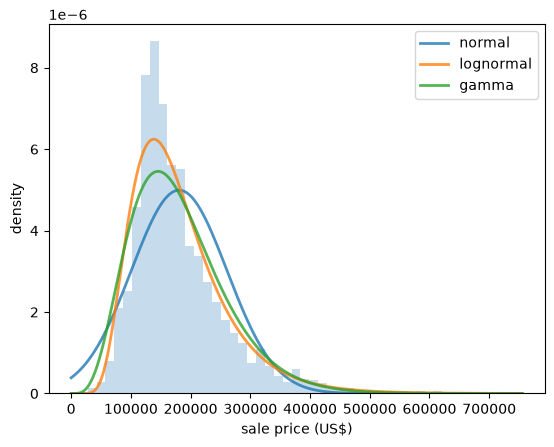

In [7]:
fits = {'normal': fit_normal(price),
        'lognormal': fit_lognormal(price),
        'gamma': fit_gamma(price)}

x_grid = np.linspace(0, price.max(), 400)

fig, ax = plt.subplots()
ax.hist(price, bins=50, density=True, alpha=0.25, color='C0')
for label, u in fits.items():
    ax.plot(x_grid, u.pdf(x_grid), lw=2, alpha=0.8, label=label)
ax.set_xlabel('sale price (US$)')
ax.set_ylabel('density')
ax.legend()
plt.show()

正态密度显然是错的：它是对称的，而数据并不对称，而且它还在负价格上赋予了权重。

另外两个看起来是合理的。

要在它们之间做出选择，我们需要比看一眼图形更精确的方法。

(qq_plots)=
## Q-Q 图

**Q-Q 图**（分位数-分位数图的简称）通过将两个分布的分位数相互对照绘图来比较它们。

要将样本与拟合分布进行比较，我们先对数据排序

$$
x_{(1)} \leq x_{(2)} \leq \cdots \leq x_{(n)}
$$

$x_{(i)}$ 估计的是哪个分位数？

回想一下 {doc}`observed_distributions` 中的内容，ECDF 在每个观测点处跳升 $1/n$。

在 $x_{(i)}$ 处，它从 $(i-1)/n$ 跳升到 $i/n$。

换句话说，有一部分 $(i-1)/n$ 的观测值严格小于 $x_{(i)}$，而有一部分 $i/n$ 的观测值小于或等于它。

所以数据并没有唯一确定 $x_{(i)}$ 所要估计的那个分位数——它们提供的是一个小区间。

通常的折中做法是取中间值，将 $x_{(i)}$ 视为阶数为 $(i - 0.5)/n$ 的分位数的估计值。

这种选择还避免了样本顶端的一个问题。

如果我们使用 $i/n$，那么最大的观测值会与阶数为 $n/n = 1$ 的分位数相匹配，而对于正态分布、对数正态分布以及我们所使用的其他无界分布，该分位数为 $+\infty$。

如果拟合分布很好地描述了数据，那么 $x_{(i)}$ 应该接近该分布对应的分位数，即

$$
F^{-1} \left( \frac{i - 0.5}{n} \right)
$$

```{note}
还有其他惯例在使用，例如 $i/(n+1)$ 和 $(i - 0.375)/(n + 0.25)$。

它们被称为*绘图位置*，不同的选择只会影响图形的两端，且随着 $n$ 的增长，其影响会缩小。
```

因此，我们将拟合出的分位数绘制在横轴上，样本值绘制在纵轴上。

一个良好的拟合会将点落在 45 度线上。

In [8]:
def qq_plot(sample, u, ax, **kwargs):
    "Plot sample quantiles against the quantiles of the distribution u."
    x_sorted = np.sort(sample)
    n = len(x_sorted)
    p = (np.arange(1, n+1) - 0.5) / n
    ax.plot(u.ppf(p), x_sorted, '.', ms=3, alpha=0.6, **kwargs)
    lo, hi = u.ppf(p[0]), u.ppf(p[-1])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=2)
    ax.set_xlabel('fitted quantiles')
    ax.set_ylabel('sample quantiles')

让我们从一个我们预期会拟合良好的例子开始。

在 {doc}`observed_distributions` 中，我们发现美国成年女性的身高样本偏度和超额峰度都接近于零。

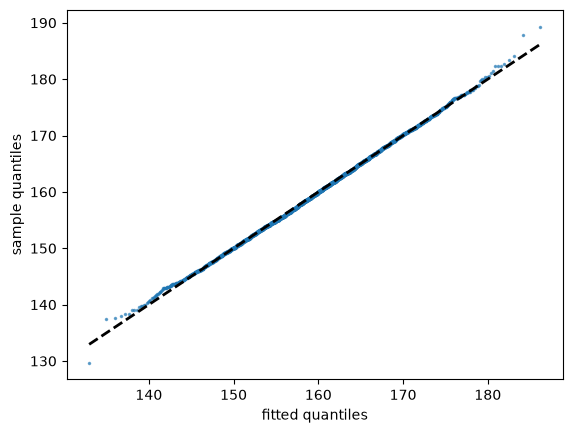

In [9]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/us_adult_heights.csv')
heights = pd.read_csv(url)
female = heights[heights['sex'] == 'female']['height_cm']

fig, ax = plt.subplots()
qq_plot(female, fit_normal(female), ax)
plt.show()

这些点几乎完全落在直线上，只是在两端有轻微的偏离，因为样本中在这些区域的观测值较少，分位数估计带有噪声。

现在让我们尝试将房价数据与拟合的正态分布进行比较。

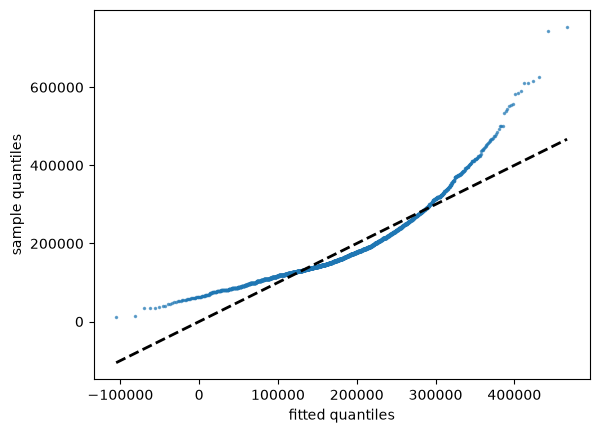

In [10]:
fig, ax = plt.subplots()
qq_plot(price, fit_normal(price), ax)
plt.show()

这是一幅截然不同的图景。

点偏离了直线，而且这种偏离有明确的含义：靠右侧的样本分位数远大于拟合分位数，这说明数据的右尾比正态分布所允许的要长得多。

偏离的形状告诉我们拟合失败的方式。

- 像这里一样向上弯曲的点表示右偏。
- 呈 S 形的点——左侧在直线下方，右侧在直线上方——表示数据的*两侧*尾部都比拟合分布更重。

让我们通过取对数来检验第二种情况，我们知道取对数会使房价数据大致对称。

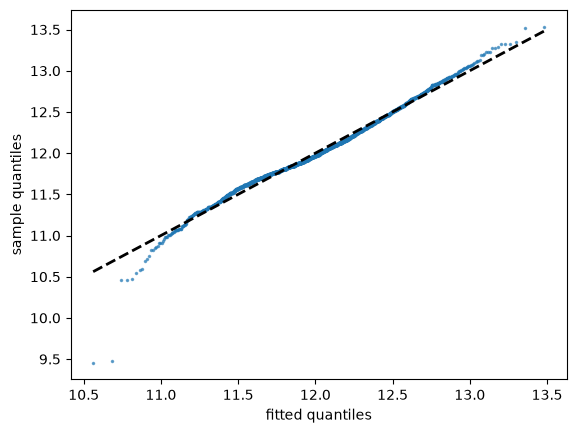

In [11]:
log_price = np.log(price)

fig, ax = plt.subplots()
qq_plot(log_price, fit_normal(log_price), ax)
plt.show()

弯曲消失了，这证实了我们在 {doc}`observed_distributions` 中通过样本偏度得到的结论。

```{note}
`statsmodels` 包提供了 `sm.qqplot`，它可以用一行代码生成此类图形，默认将数据与正态分布进行比较。

我们之所以自己构建了一个版本，部分原因是这种构造本身值得理解，部分原因是我们的版本可以将数据与我们选择的任何分布进行比较，正如我们下面所做的那样。
```

## 科尔莫戈罗夫-斯米尔诺夫统计量

Q-Q 图很有信息量，但它们需要我们对图形做出判断。

有时我们想要一个单一的数字来衡量数据与拟合分布之间的差距。

一种自然的度量方法是，将我们在 {doc}`observed_distributions` 中接触过的数据的 ECDF 与拟合分布的 CDF 进行比较。

**科尔莫戈罗夫-斯米尔诺夫统计量**是两者之间最大的垂直差距：

$$
D = \max_x \, | F_n(x) - F(x) |
$$

由于 $F_n$ 只在观测值处跳跃，我们可以通过检查每次跳跃前后的差距来计算 $D$。

In [12]:
def ks_statistic(sample, u):
    "Largest vertical distance between the ECDF of the sample and the CDF of u."
    x_sorted = np.sort(sample)
    n = len(x_sorted)
    F = u.cdf(x_sorted)
    above = np.arange(1, n+1) / n - F     # gap just after each jump
    below = F - np.arange(0, n) / n       # gap just before each jump
    return max(above.max(), below.max())

让我们通过绘制对数价格的 ECDF 与拟合 CDF，以及取得最大值的那个差距，来看看它衡量的是什么。

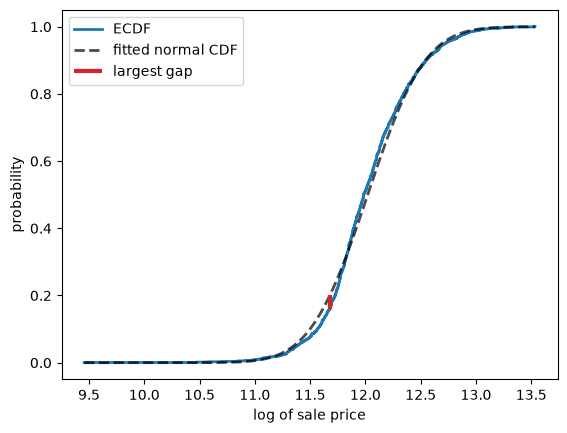

In [13]:
u = fit_normal(log_price)
x_sorted = np.sort(log_price)
n = len(x_sorted)
F = u.cdf(x_sorted)

# locate the largest gap
gaps = np.maximum(np.arange(1, n+1) / n - F, F - np.arange(0, n) / n)
i = gaps.argmax()

fig, ax = plt.subplots()
ax.step(x_sorted, np.arange(1, n+1) / n, where='post', lw=2, label='ECDF')
x_grid = np.linspace(x_sorted[0], x_sorted[-1], 200)
ax.plot(x_grid, u.cdf(x_grid), 'k--', lw=2, alpha=0.7, label='fitted normal CDF')
ax.vlines(x_sorted[i], F[i], (i+1) / n, color='C3', lw=3, label='largest gap')
ax.set_xlabel('log of sale price')
ax.set_ylabel('probability')
ax.legend()
plt.show()

In [14]:
ks_statistic(log_price, u)

0.041302695555679836

这个统计量很小，这告诉我们 ECDF 从未与拟合的 CDF 相差太远。

```{note}
你可能会认为，现在我们可以*检验*数据是否来自拟合的分布，只需判断 $D$ 是否大于纯粹由随机性所能产生的值。

这正是科尔莫戈罗夫-斯米尔诺夫检验所做的事情，`scipy` 将其实现为 `scipy.stats.kstest`。

我们在这里不深入讨论它，因为它需要知道当分布确实是正确的时候 $D$ 的行为方式，而这需要比我们目前所展开的更多理论。

这里还有一个陷阱：通常的理论假设分布是事先指定的，而我们却是用同一份数据来选择其参数的。
```


(choosing_class)=
## 选择参数类

现在我们有了一种在候选类别之间做出选择的方法。

对于每个类别，我们通过矩方法拟合参数，然后计算 $D$。

$D$ 最小的类别就是其 CDF 最接近数据的那个。

让我们将其应用到房价数据上。

In [15]:
results = pd.Series({label: ks_statistic(price, u) for label, u in fits.items()})
results.sort_values()

lognormal    0.053044
gamma        0.070460
normal       0.123422
dtype: float64

对数正态分布胜出，伽马分布位居第二，正态分布则远远落后于第三。

这与我们在 {doc}`observed_distributions` 中的发现一致，当时对价格数据取对数后得到的样本偏度几乎恰好为零。

以下是三个拟合的 CDF 与数据的 ECDF 的对比，展示了同样的排名。

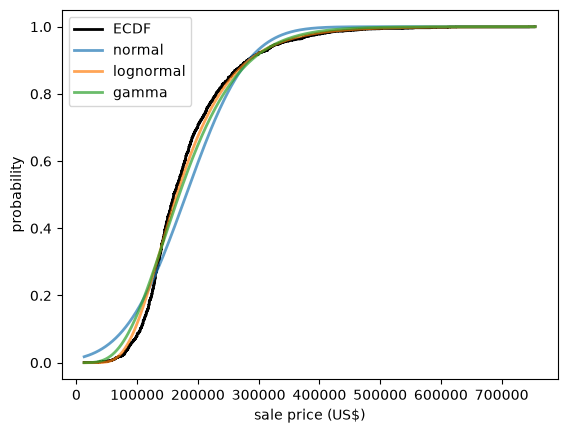

In [16]:
fig, ax = plt.subplots()
ax.step(np.sort(price), np.arange(1, len(price)+1) / len(price),
        where='post', color='k', lw=2, label='ECDF')
x_grid = np.linspace(price.min(), price.max(), 400)
for label, u in fits.items():
    ax.plot(x_grid, u.cdf(x_grid), lw=2, alpha=0.7, label=label)
ax.set_xlabel('sale price (US$)')
ax.set_ylabel('probability')
ax.legend()
plt.show()

这里有三点需要提醒。

首先，只有当各个类别拥有相同数量的参数时，这种比较才是公平的，正如本例中的情形。

参数更多的类别可以将自己弯曲得更贴近任何数据集，而 $D$ 并不会因此对它做出惩罚。

特别是，如果一个类别是另一个类别的特例，那么较大的类别永远不会表现得更差。

其次，$D$ 在分布的中部最为敏感，因为那里的 CDF 变化很快，而在尾部最不敏感。

如果我们主要关心极端结果——这在经济学和金融学中经常出现——那么一个较小的 $D$ 可能会产生误导。

第三，胜出者只是我们恰好尝试过的候选者中最好的一个。

这里的结果并不能告诉我们胜出的类别是对数据的良好描述——只能说明它比其他备选方案更好。

我们在下面进一步讨论这一点。

## 计数数据

到目前为止，我们的数据都是连续型的。

矩方法同样适用于离散数据。

考虑**泊松**分布，我们在 {doc}`prob_dist` 中将其作为固定时间间隔内事件数量的模型接触过。

它只有一个参数 $\lambda$，其均值为 $\lambda$，因此矩方法给出

$$
\hat \lambda = \bar x
$$

让我们把它应用到足球比赛中的进球数上。

该数据集包含英格兰超级联赛十个赛季中每场比赛的全场比分。

In [17]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/epl_match_goals.csv')
matches = pd.read_csv(url)
matches.head()

,season,date,home_team,away_team,home_goals,away_goals
0,2015-16,2015-08-08,Manchester United,Tottenham Hotspur,1,0
1,2015-16,2015-08-08,AFC Bournemouth,Aston Villa,0,1
2,2015-16,2015-08-08,Everton FC,Watford FC,2,2
3,2015-16,2015-08-08,Leicester City,Sunderland AFC,4,2
4,2015-16,2015-08-08,Norwich City,Crystal Palace,1,3


我们关心的是每场比赛的总进球数。

In [18]:
goals = matches['home_goals'] + matches['away_goals']
len(goals), goals.mean()

(3800, 2.83)

泊松分布有一个不寻常的性质：其方差等于均值。

这为我们提供了一个可以在拟合之前使用的诊断方法。

In [19]:
goals.mean(), goals.var()

(2.83, 2.7770939720979206)

这两个值很接近，这是令人鼓舞的。

让我们拟合分布，并将拟合的概率与观测频率进行比较。

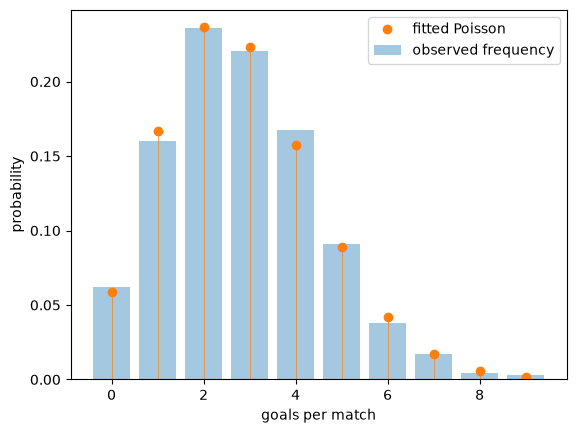

In [20]:
u = scipy.stats.poisson(goals.mean())

counts = goals.value_counts().sort_index()
frequencies = counts / counts.sum()
S = np.arange(counts.index.max() + 1)

fig, ax = plt.subplots()
ax.bar(counts.index, frequencies, alpha=0.4, label='observed frequency')
ax.plot(S, u.pmf(S), linestyle='', marker='o', color='C1', label='fitted Poisson')
ax.vlines(S, 0, u.pmf(S), lw=0.5, color='C1')
ax.set_xlabel('goals per match')
ax.set_ylabel('probability')
ax.legend()
plt.show()

拟合效果良好。

这是一个众所周知的经验规律，其原因值得说明：进球是罕见事件，在整场比赛过程中以大致恒定的速率发生，并且彼此之间基本独立。

这些正是泊松分布产生所需要的条件。

## 当正态分布失效时

当我们在上面 {ref}`比较各个类别 <choosing_class>` 时，我们列出了一系列候选类别，对每一个进行拟合，并保留 KS 距离最小的那个。

这样的程序总能产生一个胜出者。

但重要的是要记住，胜出者仍然可能是对数据的糟糕描述，因为它只是我们恰好尝试过的候选者中最好的一个。

补救的方法是既要评估拟合的排名，也要观察拟合本身，当它失败时，用它失败的方式来启发我们找到更好的候选方案。

让我们回到我们在 {doc}`observed_distributions` 中研究过的亚马逊股票的月度收益率，看看这如何发挥作用。

In [21]:
data = yf.download('AMZN', '2000-1-1', '2024-1-1', interval='1mo')
prices = data['Close']['AMZN']
returns = prices.pct_change().dropna() * 100

[*********************100%***********************]  1 of 1 completed


收益率有正有负，所以在我们的连续型类别中，只有正态分布可用。

让我们看看 Q-Q 图。

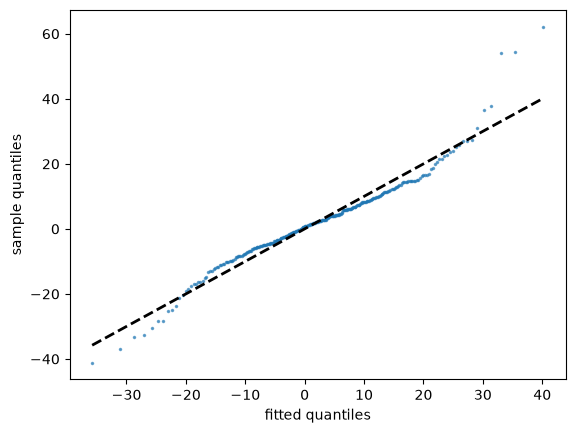

In [22]:
fig, ax = plt.subplots()
qq_plot(returns, fit_normal(returns), ax)
plt.show()

这就是上面描述过的 S 形：最小的收益率比拟合的正态分布所预测的更负，而最大的收益率则更正。

换句话说，数据的两个尾部都比正态分布所允许的更重。

现在让我们计算 KS 统计量。

In [23]:
ks_statistic(returns, fit_normal(returns))

0.06799509014059524

单独来看，这个数字看起来并不显眼。

```{note}
不应该在不同大小的数据集之间比较 $D$ 的值。

即使拟合分布完全正确，$D$ 也会随着 $n$ 的增长而缩小，所以来自小样本的一个小数值的意义不如来自大样本的相同数值。

这里的重点不是 $D$ 比之前某个数字更小或更大，而是它完全没有暗示 Q-Q 图所清楚展示出来的问题。
```

这说明了上面提到的第二个警告。

正态分布对收益率数据的中部描述得相当不错，而这正是 KS 统计量所关注的区域。

问题出在尾部，而尾部恰恰是资产收益率研究最关心的部分，因为它们包含着巨大的损失。

这里的教训是，单一的汇总数字永远无法替代对数据本身的观察。

### 一个尾部更重的候选者

Q-Q 图不仅告诉我们正态分布失效了。

它还告诉我们它*是如何*失效的：数据的尾部比拟合的正态分布更重。

这指向了一个补救办法，即尝试一个尾部更重的类别。

其中一个这样的类别是**学生 t 分布**，它像正态分布一样对称且呈钟形，但带有一个额外的参数 $\nu > 0$，称为*自由度*，用于控制尾部的权重。

较小的 $\nu$ 值会产生重尾，而当 $\nu \to \infty$ 时，该分布收敛到正态分布。

平移和缩放使我们得到一个三参数类别，因此矩方法需要用到三个矩。

前两个是均值和方差，如前所述。

第三个矩在这里没有用，因为该类别的每个成员都是对称的，因此无论 $\nu$ 取何值，偏度都为零。

所以我们改用第四个矩，利用该类别的成员在 $\nu > 4$ 时具有超额峰度 $6/(\nu - 4)$ 这一事实。

将其与样本超额峰度 $\hat K$ 匹配，得到

$$
\hat \nu = 4 + \frac{6}{\hat K}
$$

然后方差 $\nu \sigma^2 / (\nu - 2)$ 便确定了尺度参数。

In [24]:
def fit_t(sample):
    m, s = sample.mean(), sample.std()
    ν = 4 + 6 / scipy.stats.kurtosis(sample)
    return scipy.stats.t(df=ν, loc=m, scale=s * np.sqrt((ν - 2) / ν))

u = fit_t(returns)
u.kwds['df']

5.804215121689082

让我们看看它是否表现得更好。

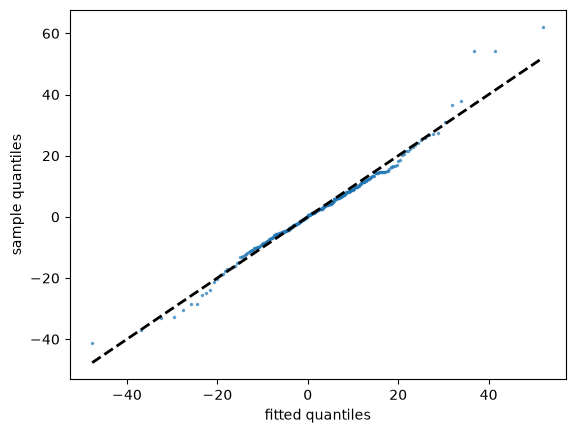

In [25]:
fig, ax = plt.subplots()
qq_plot(returns, u, ax)
plt.show()

系统性的 S 形消失了。

除了少数极端观测值——此时拟合的分位数略微超出——其余的点都紧贴在直线上。

KS 距离也下降了约 40%。

In [26]:
ks_statistic(returns, u)

0.04114771740390599

所以，并非没有什么分布能拟合这些数据——我们只是还没有尝试一个允许重尾的类别。

```{note}
我们不应对拟合出的 $\nu$ 值给予过多的重视。

我们对它的估计来自样本峰度，这是一个四阶矩，而正是在尾部较重的情况下，高阶矩的估计才会变得不精确。

改用最大似然法来拟合这个分布，正如我们在 {doc}`mle` 中所做的那样，会得到 $\nu \approx 3.6$ 而不是 $5.8$，且 KS 距离会更小。

矩方法简单而通用，但它并不总是对数据的最佳利用方式。
```

具有重尾的分布，以及它们如何改变我们对风险的思考方式，是 {doc}`heavy_tails` 的主题。

## 练习

下一个数据集记录了 2000 年至 2024 年间日本周边地区发生的所有 5 级及以上地震，数据来源为
[美国地质调查局](https://earthquake.usgs.gov/earthquakes/search/)。

In [27]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/japan_earthquakes.csv')
quakes = pd.read_csv(url)
quakes.head()

,time,magnitude,latitude,longitude,depth_km
0,2000-01-09T04:02:23.680Z,5.4,37.280,141.515,56.0
1,2000-01-10T16:40:42.240Z,5.7,27.350,139.979,453.2
2,2000-01-11T23:43:56.450Z,5.1,40.498,122.994,10.0
3,2000-01-13T18:52:12.030Z,5.2,44.393,149.492,48.9
4,2000-01-23T07:40:04.900Z,5.5,30.239,130.768,42.9


```{exercise}
:label: fit_ex1

地震常常被建模为以某个恒定速率随机且独立地发生。

如果这是真的，那么连续两次地震之间的时间间隔应服从指数分布。

利用上面的数据，计算连续两次地震之间的天数间隔，用矩方法拟合一个指数分布，并评估其拟合效果。

（指数分布有一个参数 $\lambda$，均值为 $1/\lambda$。）

这个模型是否成立？
```

```{solution-start} fit_ex1
:class: dropdown
```

以下是一种解法。

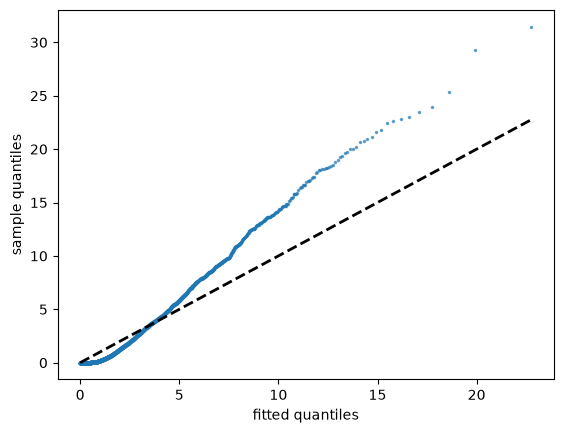

In [28]:
times = pd.to_datetime(quakes['time'], format='ISO8601')
gaps = times.diff().dropna().dt.total_seconds() / (60 * 60 * 24)

u = scipy.stats.expon(scale=gaps.mean())

fig, ax = plt.subplots()
qq_plot(gaps, u, ax)
plt.show()

拟合效果很差，最大的间隔时间远远超出了指数分布所预测的值。

第二个诊断方法让问题更加清晰。

对于指数分布，标准差等于均值。

In [29]:
gaps.mean(), gaps.std()

(2.5645754636399616, 3.765224536996305)

标准差约为均值的一倍半，因此数据的变异性远大于该模型所允许的程度。

原因在于地震*并非*相互独立。

大地震之后会有余震，因此事件是成簇到来的，中间穿插着长时间的平静期。

我们可以通过统计每月的事件数直接看到这一点。

In [30]:
monthly = times.dt.to_period('M').value_counts().sort_index()
monthly.mean(), monthly.var()

/tmp/ipykernel_5979/2771413300.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = times.dt.to_period('M').value_counts().sort_index()


(11.856666666666667, 1148.9793868450386)

如果到达过程是泊松过程，这两个数字应该大致相等。

而这里方差是均值的许多倍，这正是聚集性的标志。

这与 {doc}`observed_distributions` 中关于独立性的讨论相呼应：只有当观测值带来新信息时，样本才能告诉我们关于分布的信息，而余震大多只是告诉我们主震已经告诉过我们的事情。

```{solution-end}
```

```{exercise}
:label: fit_ex2

在 {doc}`observed_distributions` 中，我们发现日本的死亡年龄的样本偏度约为 $-1.6$。

用矩方法为该数据拟合一个正态分布，并用 Q-Q 图展示其失效之处。

点向哪个方向弯曲？为什么？
```

```{solution-start} fit_ex2
:class: dropdown
```

以下是一种解法。

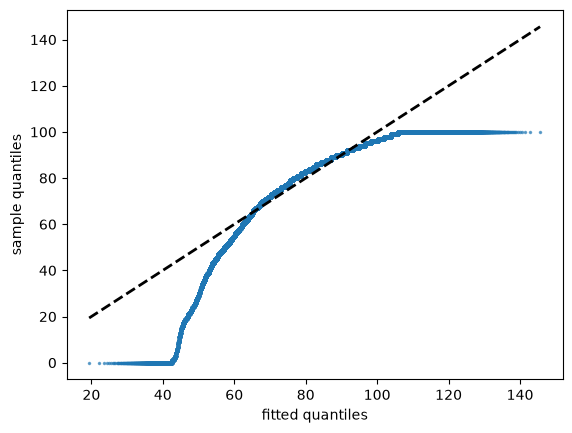

In [31]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/japan_deaths_by_age.csv')
deaths = pd.read_csv(url)
age_at_death = np.repeat(deaths['age'], deaths['deaths_total'])

fig, ax = plt.subplots()
qq_plot(age_at_death, fit_normal(age_at_death), ax)
plt.show()

点向下弯曲，这与房价图形的情形正好相反。

在左端，样本分位数远低于拟合分位数，因为数据在年轻年龄段有一条正态分布无法重现的长左尾。

图中还显示了第二个、与此无关的问题：右端的点沿 $y = 100$ 呈水平延伸。

这就是 {doc}`observed_distributions` 中讨论过的“100 岁及以上”类别，它将所有年龄都限定为 100。

Q-Q 图能非常清楚地展示这类记录惯例，因为它们表现为许多观测值共享同一个数值所形成的平坦区段。

```{solution-end}
```